**Code for training semantic segmentation models using the SMP library**

Import Libraries

In [1]:
import os
import ast
import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.optim import lr_scheduler

import pytorch_lightning as pl
import segmentation_models_pytorch as smp

Hyperparameters

In [2]:
MODEL_NAME = "deeplabv3plus" # Available options are: ['unet', 'unetplusplus', 'manet', 'linknet', 'fpn', 'pspnet', 'deeplabv3', 'deeplabv3plus', 'pan', 'upernet', 'segformer', 'dpt']"
ENCODER_NAME = "resnext50_32x4d" 
DEVICE_ID = 2
EPOCHS = 300
LEARNING_RATE = 1e-4
BATCH_SIZE = 64
IMAGE_SIZE = 320
SEED = 42

In [3]:
DATA_DIR = r'/home/c/choton/beemachine/datasets/Others/fish-vista' # Define the Fish-Vista dataset directory

# Load the segmentation splits and check the shape
seg_train_csv = os.path.join(DATA_DIR, r'segmentation_train.csv')
seg_train_aug_csv = os.path.join(DATA_DIR, r'segmentation_train_aug.csv')
seg_val_csv = os.path.join(DATA_DIR, r'segmentation_val.csv')
seg_test_csv = os.path.join(DATA_DIR, r'segmentation_test.csv')
seg_train_df = pd.read_csv(seg_train_csv)
seg_train_aug_df = pd.read_csv(seg_train_aug_csv)
seg_val_df = pd.read_csv(seg_val_csv)
seg_test_df = pd.read_csv(seg_test_csv)
print(f'Shape of FishVista segmentation datasets,  train: {seg_train_df.shape}, train_aug: {seg_train_aug_df.shape}, validation: {seg_val_df.shape}, test): {seg_test_df.shape}')
print(f'Columns of the test dataset:', list(seg_test_df.columns))

# Class labels of the segmentation split
train_species = set(list(seg_train_df['standardized_species']))
val_species = set(list(seg_val_df['standardized_species']))
test_species = set(list(seg_test_df['standardized_species']))
check_val = [v for v in val_species if v not in train_species]
check_test = [v for v in test_species if v not in train_species]
print(f'The number of classes (species) are, train: {len(train_species)}, val: {len(val_species)}, test: {len(test_species)}')
print(f'Species in val but not train: {len(check_val)},  species in test but not train: {len(check_test)}')

# Read the mask labels (traits)
seg_json_path = os.path.join(DATA_DIR, 'segmentation_masks', 'seg_id_trait_map.json')
with open(seg_json_path, 'r') as json_file:
    content = json_file.read()
    seg_json = ast.literal_eval(content)
    print('Names of the mask labels (traits):')
    print(seg_json)
labels = list(seg_json.values())

Shape of FishVista segmentation datasets,  train: (4312, 11), train_aug: (25872, 3), validation: (316, 11), test): (1504, 11)
Columns of the test dataset: ['index', 'filename', 'source_filename', 'original_format', 'arkid', 'source', 'owner', 'license', 'original_url', 'family', 'standardized_species']
The number of classes (species) are, train: 2586, val: 303, test: 1224
Species in val but not train: 146,  species in test but not train: 639
Names of the mask labels (traits):
{0: 'Background', 1: 'Head', 2: 'Eye', 3: 'Dorsal fin', 4: 'Pectoral fin', 5: 'Pelvic fin', 6: 'Anal fin', 7: 'Caudal fin', 8: 'Adipose fin', 9: 'Barbel'}


In [4]:
class PartWholeDataset(Dataset):
    def __init__(self, image_dir, mask_dir, df=None, image_size=224, mask_sfx='.png', data_path=DATA_DIR):
        self.df = df
        self.mask_sfx = mask_sfx # Mask suffix "_m.png"
        self.image_size = image_size
        self.image_dir = image_dir # os.path.join(data_path, 'Images')
        self.mask_dir = mask_dir # os.path.join(data_path, 'segmentation_masks', 'images')
        self.image_names = list(self.df['filename']) # os.listdir(self.image_dir)
        # self.image_paths = [os.path.join(self.image_dir, p) for p in self.image_names]

        # transform for image
        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
        ])
        self.mask_transform = transforms.Compose([
            transforms.Resize(
                (image_size, image_size),
                interpolation=transforms.InterpolationMode.NEAREST
            ),
            transforms.PILToTensor(),  # keeps integer values
        ])
    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        # Load the image at index idx and convert to tensor
        img_name = self.image_names[idx]
        img_path = os.path.join(self.image_dir, img_name)
        img_pil = Image.open(img_path)
        img_tens = self.img_transform(img_pil)

        # Load the corresponding mask and convert to tensor
        mask_path = os.path.join(self.mask_dir, img_name)[:-4]+self.mask_sfx
        mask_pil = Image.open(mask_path)
        mask_tens = self.mask_transform(mask_pil)

        cls_label = self.df['standardized_species'][idx]
        return img_tens, mask_tens.squeeze(0), cls_label

In [5]:
imgs_path = os.path.join(DATA_DIR, 'Images')
masks_path = os.path.join(DATA_DIR, 'segmentation_masks', 'images')
aug_imgs_path = os.path.join(DATA_DIR, 'train_aug_images')
aug_masks_path = os.path.join(DATA_DIR, 'train_aug_masks')

train_dataset = PartWholeDataset(image_dir=imgs_path, mask_dir=masks_path, df=seg_train_df, image_size=IMAGE_SIZE)
train_aug_dataset = PartWholeDataset(image_dir=aug_imgs_path, mask_dir=aug_masks_path, df=seg_train_aug_df, image_size=IMAGE_SIZE, mask_sfx='_m.png')
val_dataset = PartWholeDataset(image_dir=imgs_path, mask_dir=masks_path, df=seg_val_df, image_size=IMAGE_SIZE)
test_dataset = PartWholeDataset(image_dir=imgs_path, mask_dir=masks_path, df=seg_test_df, image_size=IMAGE_SIZE)

print(f"Train: {len(train_dataset)}, Train_aug: {len(train_aug_dataset)},  Val: {len(val_dataset)}, Test: {len(test_dataset)}")
num_classes = len(labels)
print(f"Training with number of part labels (including background) = {num_classes}")
print("Part labels:", labels)

Train: 4312, Train_aug: 25872,  Val: 316, Test: 1504
Training with number of part labels (including background) = 10
Part labels: ['Background', 'Head', 'Eye', 'Dorsal fin', 'Pectoral fin', 'Pelvic fin', 'Anal fin', 'Caudal fin', 'Adipose fin', 'Barbel']


In [6]:
def visualize(**images):
    """Plot images in one row."""
    n = len(images)
    plt.figure(figsize=(16, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(" ".join(name.split("_")).title())

        # If it's an image, plot it as RGB
        if name == "image":
            # # Convert CHW to HWC for plotting
            # image = image.transpose(1, 2, 0)
            np_image = np.array(image)
            np_image = np_image.transpose(1, 2, 0)
            plt.imshow(np_image)
        else:
            plt.imshow(image, cmap="tab20")
    plt.show()

Mask shape: torch.Size([320, 320])


/tmp/ipykernel_555659/206719642.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_image = np.array(image)


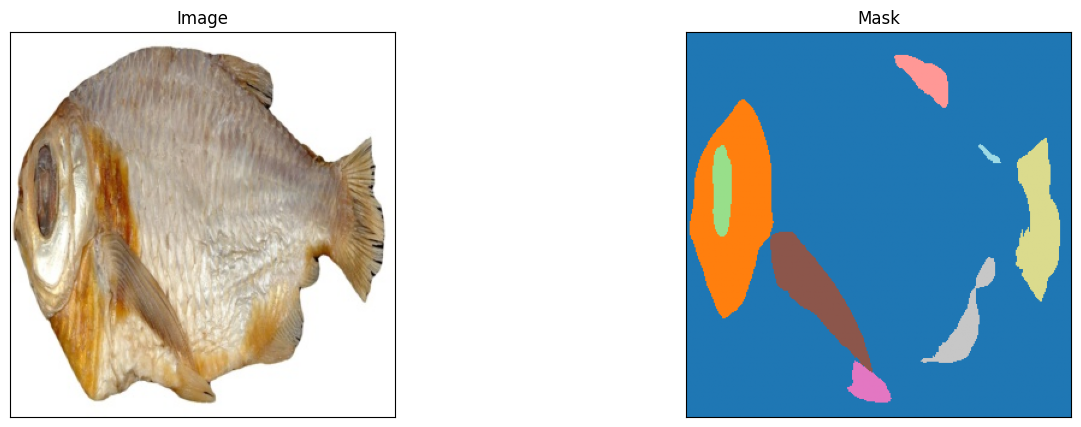

In [7]:
image, mask, _ = train_aug_dataset[0]
print(f"Mask shape: {mask.shape}")
visualize(image=image, mask=mask)

Mask shape: torch.Size([320, 320])


/tmp/ipykernel_555659/206719642.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_image = np.array(image)


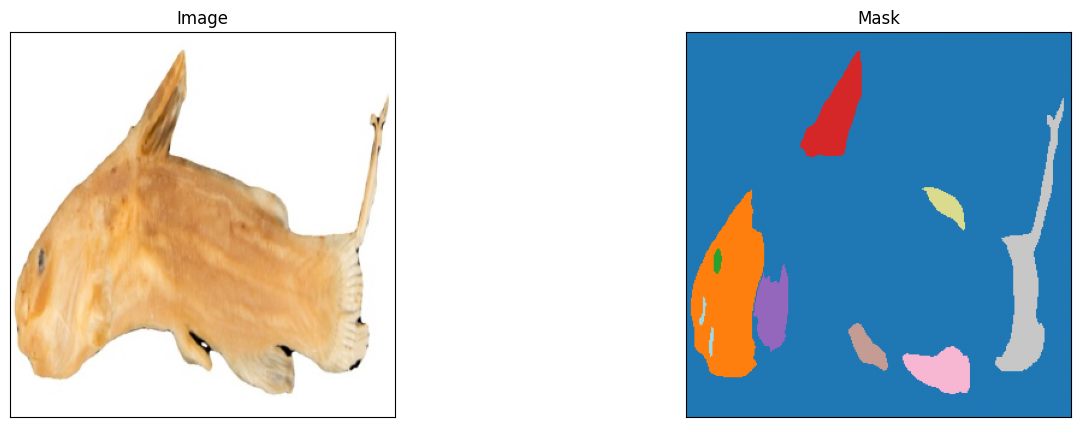

In [8]:
image, mask, _ = train_aug_dataset[30]
print(f"Mask shape: {mask.shape}")
visualize(image=image, mask=mask)

Mask shape: torch.Size([320, 320])


/tmp/ipykernel_555659/206719642.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_image = np.array(image)


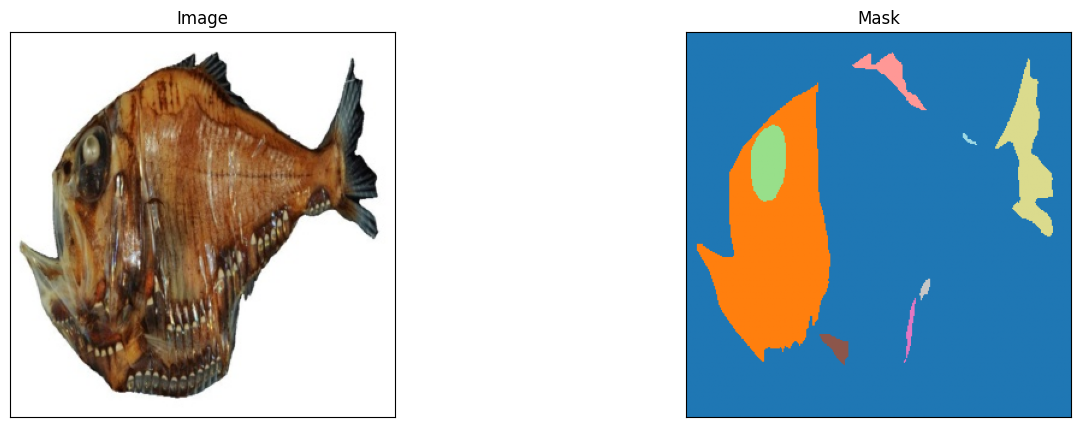

In [9]:
image, mask, _ = train_aug_dataset[786]
print(f"Mask shape: {mask.shape}")
visualize(image=image, mask=mask)

Mask shape: torch.Size([320, 320])


/tmp/ipykernel_555659/206719642.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_image = np.array(image)


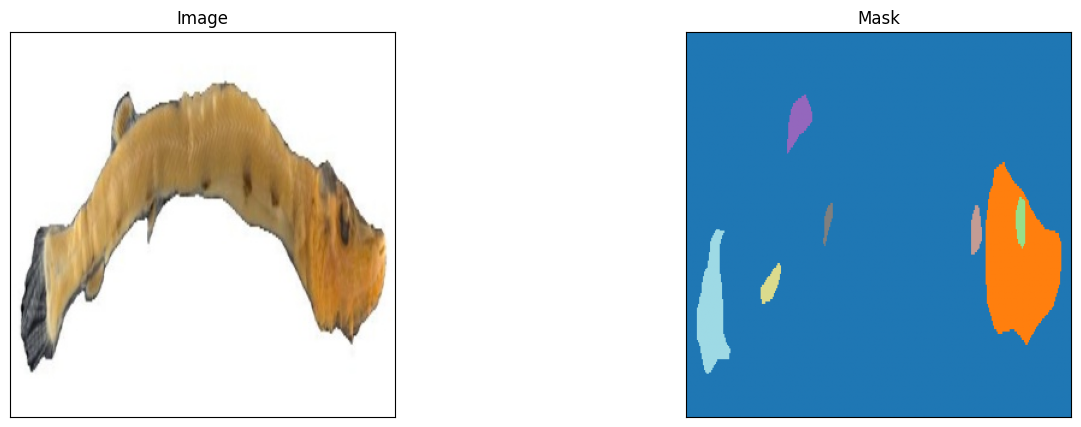

In [10]:
image, mask, _ = train_aug_dataset[3034]
print(f"Mask shape: {mask.shape}")
visualize(image=image, mask=mask)

In [11]:
# DataLoaders
train_loader = DataLoader(train_aug_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
print(f"Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}, Test: {len(test_loader.dataset)}")

Train: 25872, Val: 316, Test: 1504


In [12]:
class CamVidModel(pl.LightningModule):
    def __init__(self, arch, encoder_name, in_channels, out_classes, **kwargs):
        super().__init__()
        self.model = smp.create_model(
            arch,
            encoder_name=encoder_name,
            in_channels=in_channels,
            classes=out_classes,
            **kwargs,
        )

        # Preprocessing parameters for image normalization
        params = smp.encoders.get_preprocessing_params(encoder_name)
        self.number_of_classes = out_classes
        self.register_buffer("std", torch.tensor(params["std"]).view(1, 3, 1, 1))
        self.register_buffer("mean", torch.tensor(params["mean"]).view(1, 3, 1, 1))

        # Loss function for multi-class segmentation
        self.loss_fn = smp.losses.DiceLoss(smp.losses.MULTICLASS_MODE, from_logits=True)

        # Step metrics tracking
        self.training_step_outputs = []
        self.validation_step_outputs = []
        self.test_step_outputs = []

    def forward(self, image):
        # Normalize image
        image = (image - self.mean) / self.std
        mask = self.model(image)
        return mask

    def shared_step(self, batch, stage):
        image, mask, _ = batch

        # Ensure that image dimensions are correct
        assert image.ndim == 4  # [batch_size, channels, H, W]

        # Ensure the mask is a long (index) tensor
        mask = mask.long()

        # Mask shape
        assert mask.ndim == 3  # [batch_size, H, W]

        # Predict mask logits
        logits_mask = self.forward(image)

        assert (
            logits_mask.shape[1] == self.number_of_classes
        )  # [batch_size, number_of_classes, H, W]

        # Ensure the logits mask is contiguous
        logits_mask = logits_mask.contiguous()

        # Compute loss using multi-class Dice loss (pass original mask, not one-hot encoded)
        loss = self.loss_fn(logits_mask, mask)

        # Apply softmax to get probabilities for multi-class segmentation
        prob_mask = logits_mask.softmax(dim=1)

        # Convert probabilities to predicted class labels
        pred_mask = prob_mask.argmax(dim=1)

        # Compute true positives, false positives, false negatives, and true negatives
        tp, fp, fn, tn = smp.metrics.get_stats(
            pred_mask, mask, mode="multiclass", num_classes=self.number_of_classes
        )

        return {
            "loss": loss,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
        }

    def shared_epoch_end(self, outputs, stage):
        # Aggregate step metrics
        tp = torch.cat([x["tp"] for x in outputs])
        fp = torch.cat([x["fp"] for x in outputs])
        fn = torch.cat([x["fn"] for x in outputs])
        tn = torch.cat([x["tn"] for x in outputs])

        # Per-image IoU and dataset IoU calculations
        per_image_iou = smp.metrics.iou_score(
            tp, fp, fn, tn, reduction="micro-imagewise"
        )
        dataset_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")

        metrics = {
            f"{stage}_per_image_iou": per_image_iou,
            f"{stage}_dataset_iou": dataset_iou,
        }

        self.log_dict(metrics, prog_bar=True)

    def training_step(self, batch, batch_idx):
        train_loss_info = self.shared_step(batch, "train")
        self.training_step_outputs.append(train_loss_info)
        return train_loss_info

    def on_train_epoch_end(self):
        self.shared_epoch_end(self.training_step_outputs, "train")
        self.training_step_outputs.clear()

    def validation_step(self, batch, batch_idx):
        valid_loss_info = self.shared_step(batch, "valid")
        self.validation_step_outputs.append(valid_loss_info)
        return valid_loss_info

    def on_validation_epoch_end(self):
        self.shared_epoch_end(self.validation_step_outputs, "valid")
        self.validation_step_outputs.clear()

    def test_step(self, batch, batch_idx):
        test_loss_info = self.shared_step(batch, "test")
        self.test_step_outputs.append(test_loss_info)
        return test_loss_info

    def on_test_epoch_end(self):
        self.shared_epoch_end(self.test_step_outputs, "test")
        self.test_step_outputs.clear()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=2e-4)
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",
                "frequency": 1,
            },
        }

In [13]:
model = CamVidModel(MODEL_NAME, ENCODER_NAME, in_channels=3, out_classes=num_classes)

In [14]:
trainer = pl.Trainer(max_epochs=EPOCHS, log_every_n_steps=1, devices=[DEVICE_ID])

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
